✓ Saved: pipeline_horizontal.png
✓ Saved: pipeline_horizontal.svg


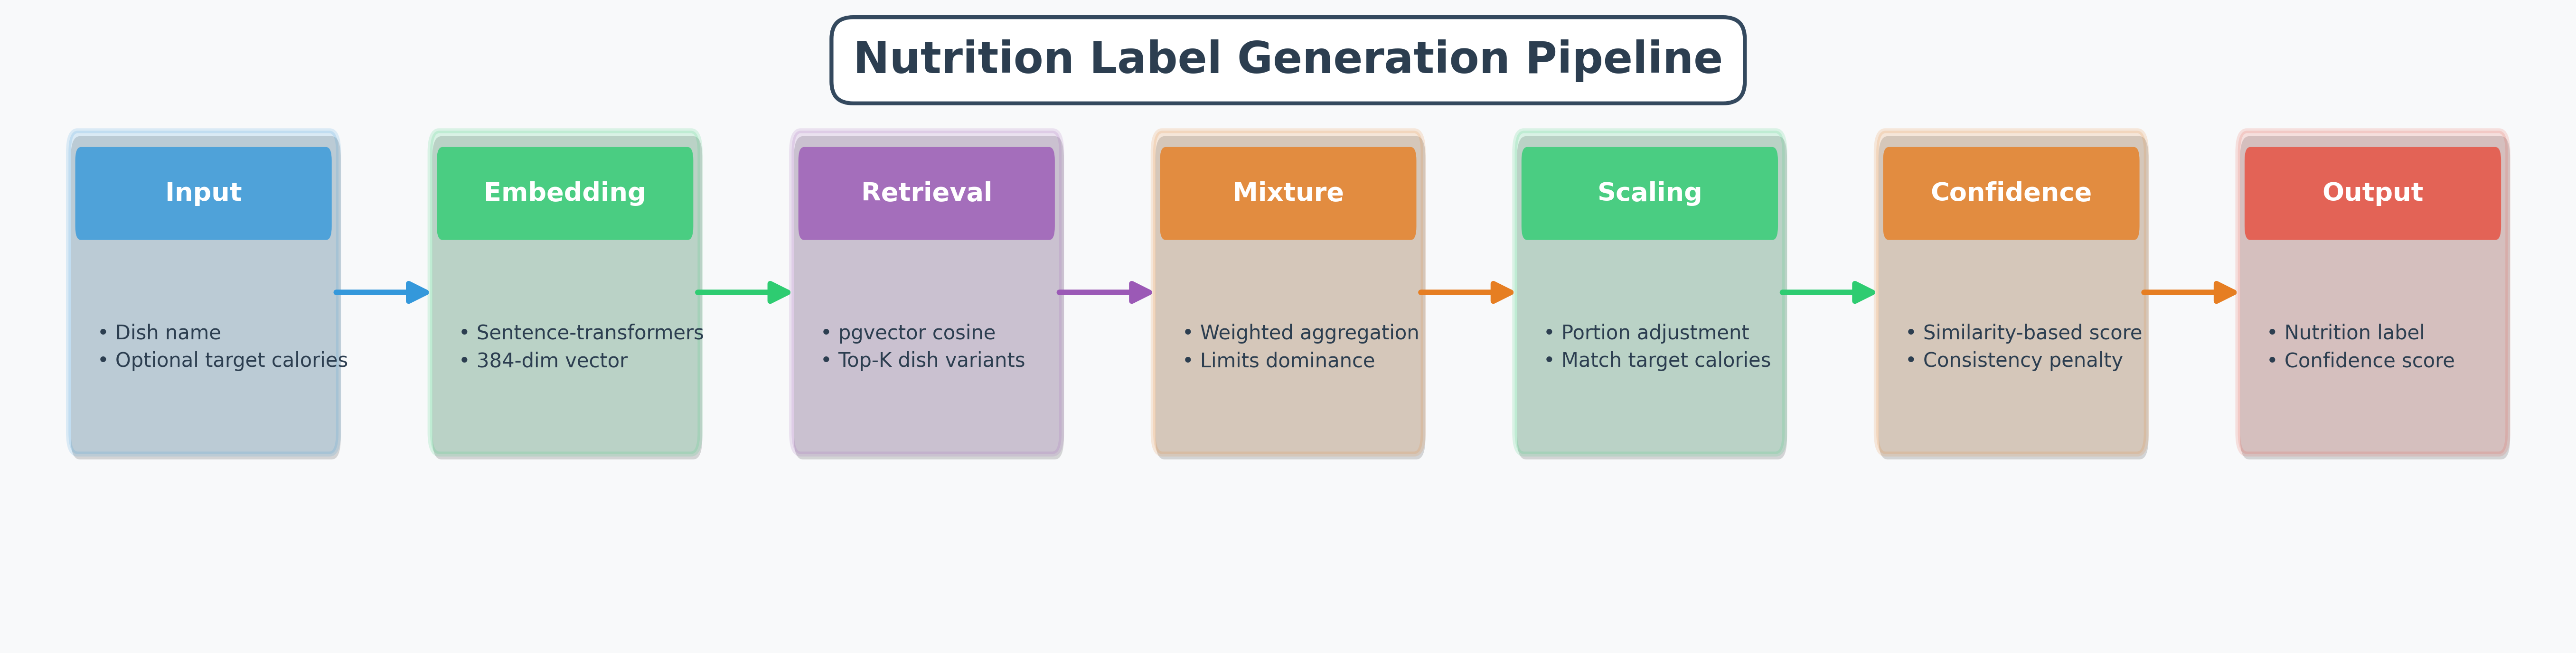

In [10]:
"""
Horizontal pipeline diagram generator (matplotlib)

Creates a clean, poster-friendly, horizontal version of your pipeline:
Input -> Embedding -> Retrieval -> Mixture -> Scaling -> Confidence -> Output

Outputs:
- pipeline_horizontal.png
- pipeline_horizontal.svg  (recommended for posters, stays sharp)

Usage:
  python make_pipeline_horizontal.py
"""

from matplotlib import pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.patches as mpatches


def add_box(ax, x, y, w, h, title, bullets, color, fontsize=12):
    # Drop shadow for depth
    shadow = FancyBboxPatch(
        (x + 0.02, y - 0.02), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=0,
        edgecolor="none",
        facecolor="gray",
        alpha=0.3,
        zorder=1,
    )
    ax.add_patch(shadow)
    
    # Main rounded rectangle with color
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=2.5,
        edgecolor=color,
        facecolor=color,
        alpha=0.15,
        zorder=2,
    )
    ax.add_patch(box)

    # Title with colored background
    title_height = h * 0.28
    title_box = FancyBboxPatch(
        (x + 0.05, y + h - title_height - 0.05), w - 0.1, title_height,
        boxstyle="round,pad=0.01,rounding_size=0.05",
        linewidth=0,
        edgecolor="none",
        facecolor=color,
        alpha=0.8,
        zorder=3,
    )
    ax.add_patch(title_box)
    
    ax.text(
        x + w / 2,
        y + h - title_height / 2 - 0.05,
        title,
        ha="center",
        va="center",
        fontsize=fontsize + 2,
        fontweight="bold",
        color="white",
        zorder=4,
    )

    # Bullets with better spacing - positioned to stay within box
    bullet_text = "\n".join([f"• {b}" for b in bullets])
    # Calculate available space for bullets (below title box)
    bullet_area_height = y + h - title_height - 0.05
    bullet_y = y + (bullet_area_height - y) * 0.48  # Center bullets in available space
    
    ax.text(
        x + w * 0.1,  # More padding from left edge
        bullet_y,
        bullet_text,
        ha="left",
        va="center",
        fontsize=fontsize - 1,  # Slightly smaller for better fit
        color="#2c3e50",
        linespacing=1.5,
        zorder=4,
        weight="medium",
    )


def add_arrow(ax, x1, y1, x2, y2, color="#34495e"):
    # Main arrow
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>",
        mutation_scale=22,
        linewidth=2.8,
        color=color,
        shrinkA=0,
        shrinkB=0,
        zorder=5,
    )
    ax.add_patch(arrow)


def main():
    # Layout settings
    title = "Nutrition Label Generation Pipeline"

    # Box size and spacing - slightly taller boxes to accommodate text better
    w, h = 2.35, 1.15
    gap = 0.85
    y = 0.7
    x0 = 0.5

    # Color scheme - professional and poster-friendly
    colors = {
        "input": "#3498db",      # Blue
        "process": "#2ecc71",    # Green
        "retrieval": "#9b59b6",  # Purple
        "analysis": "#e67e22",   # Orange
        "output": "#e74c3c",     # Red
    }

    steps = [
        ("Input", ["Dish name", "Optional target calories"], colors["input"]),
        ("Embedding", ["Sentence-transformers", "384-dim vector"], colors["process"]),
        ("Retrieval", ["pgvector cosine", "Top-K dish variants"], colors["retrieval"]),
        ("Mixture", ["Weighted aggregation", "Limits dominance"], colors["analysis"]),
        ("Scaling", ["Portion adjustment", "Match target calories"], colors["process"]),
        ("Confidence", ["Similarity-based score", "Consistency penalty"], colors["analysis"]),
        ("Output", ["Nutrition label", "Confidence score"], colors["output"]),
    ]

    # Figure sizing: make it wide, not tall
    fig_w = 18
    fig_h = 4.5
    fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=300)
    
    # Light background for better poster appearance
    fig.patch.set_facecolor('#f8f9fa')
    ax.set_facecolor('#f8f9fa')

    # Title with better styling
    ax.text(
        0.5,
        0.96,
        title,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=22,
        fontweight="bold",
        color="#2c3e50",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#34495e", linewidth=2),
    )

    # Draw boxes
    xs = []
    for i, (name, bullets, color) in enumerate(steps):
        x = x0 + i * (w + gap)
        xs.append(x)
        add_box(ax, x, y, w, h, name, bullets, color, fontsize=11)

    # Draw arrows between boxes with matching colors
    for i in range(len(steps) - 1):
        x1 = xs[i] + w
        y1 = y + h / 2
        x2 = xs[i + 1]
        y2 = y + h / 2
        # Use color from current step
        arrow_color = steps[i][2]
        add_arrow(ax, x1, y1, x2, y2, arrow_color)

    # Frame and axes cleanup
    total_w = x0 + len(steps) * w + (len(steps) - 1) * gap + 0.5
    ax.set_xlim(0, total_w)
    ax.set_ylim(0, 2.3)
    ax.axis("off")

    plt.tight_layout(pad=0.4)

    # Save outputs
    fig.savefig("pipeline_horizontal.png", bbox_inches="tight", dpi=300, facecolor='#f8f9fa')
    fig.savefig("pipeline_horizontal.svg", bbox_inches="tight", facecolor='#f8f9fa')
    print("✓ Saved: pipeline_horizontal.png")
    print("✓ Saved: pipeline_horizontal.svg")


if __name__ == "__main__":
    main()

✓ Saved: system_architecture.png
✓ Saved: system_architecture.svg


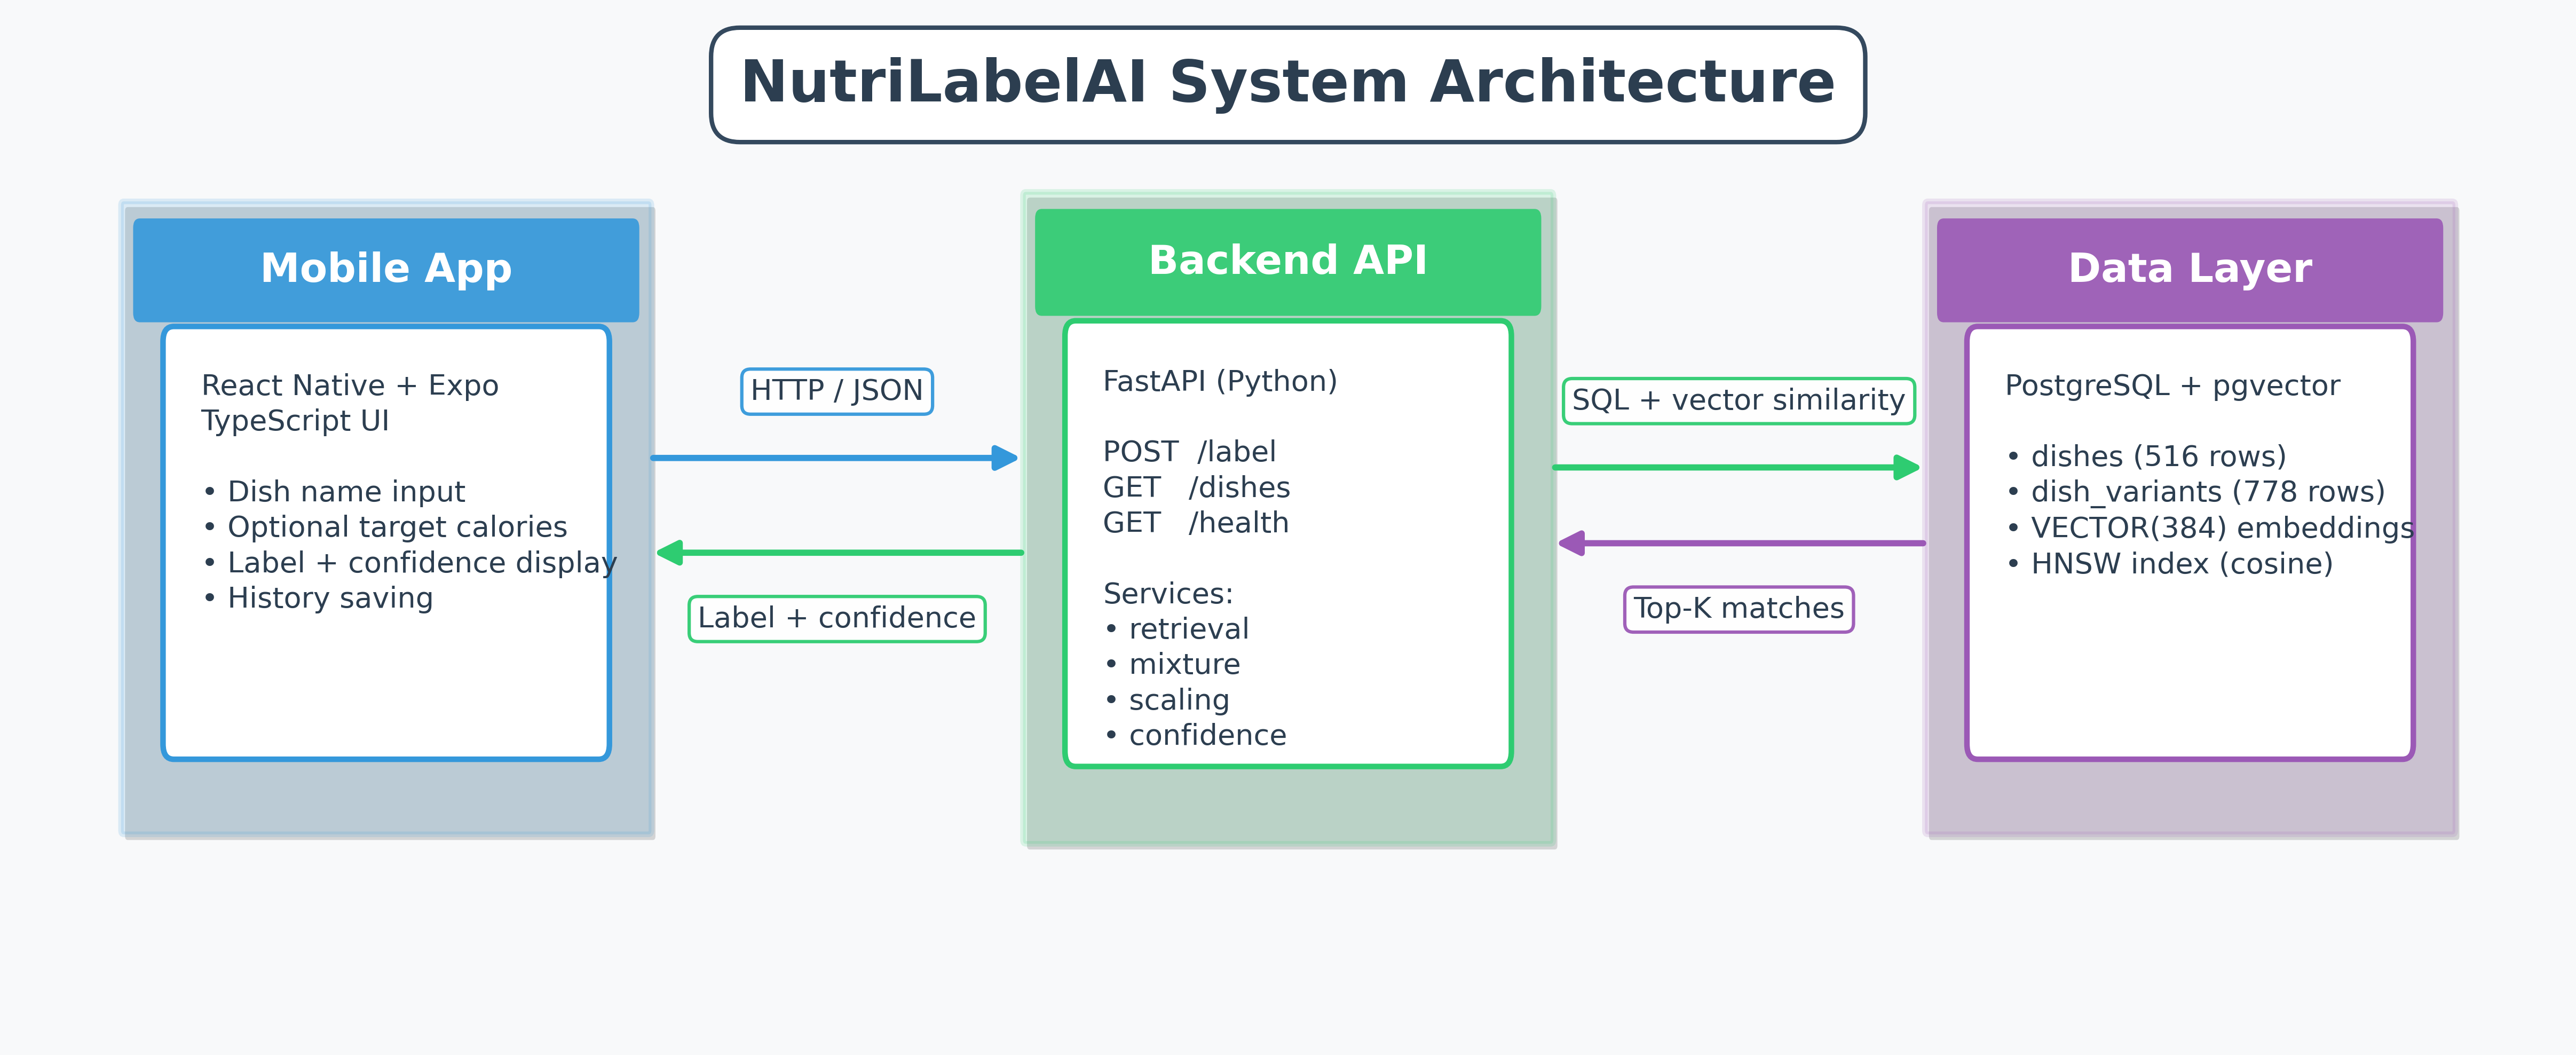

In [18]:
"""
NutriLabelAI System Architecture diagram generator (matplotlib)

Creates a clean architecture diagram like your screenshot:
Mobile App  <->  Backend API  <->  Data Layer

Outputs:
- system_architecture.png
- system_architecture.svg (best for posters)

Run:
  python make_system_architecture.py
"""

from matplotlib import pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch


def rounded_panel(ax, x, y, w, h, title, inner_lines, color="#3498db", *,
                  title_fs=18, body_fs=13):
    # Drop shadow for depth
    shadow = FancyBboxPatch(
        (x + 0.03, y - 0.03), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=0,
        edgecolor="none",
        facecolor="gray",
        alpha=0.3,
        zorder=1,
    )
    ax.add_patch(shadow)
    
    # Outer container with color
    outer = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=2.5,
        edgecolor=color,
        facecolor=color,
        alpha=0.15,
        zorder=2,
    )
    ax.add_patch(outer)

    # Title bar with colored background
    title_height = h * 0.16
    title_box = FancyBboxPatch(
        (x + 0.08, y + h - title_height - 0.08), w - 0.16, title_height,
        boxstyle="round,pad=0.01,rounding_size=0.05",
        linewidth=0,
        edgecolor="none",
        facecolor=color,
        alpha=0.9,
        zorder=3,
    )
    ax.add_patch(title_box)
    
    # Title (top, centered, white text on colored background)
    ax.text(
        x + w / 2, y + h - title_height / 2 - 0.08,
        title,
        ha="center", va="center",
        fontsize=title_fs,
        fontweight="bold",
        color="white",
        zorder=4,
    )

    # Inner rounded box
    pad = 0.08
    ix, iy = x + w * pad, y + h * 0.12
    iw, ih = w * (1 - 2 * pad), h * 0.68
    inner = FancyBboxPatch(
        (ix, iy), iw, ih,
        boxstyle="round,pad=0.02,rounding_size=0.08",
        linewidth=2.5,
        edgecolor=color,
        facecolor="white",
        zorder=3,
    )
    ax.add_patch(inner)

    # Inner text with better formatting
    text = "\n".join(inner_lines)
    ax.text(
        ix + iw * 0.08, iy + ih * 0.90,
        text,
        ha="left", va="top",
        fontsize=body_fs,
        color="#2c3e50",
        linespacing=1.35,
        weight="medium",
        zorder=4,
    )


def arrow(ax, x1, y1, x2, y2, label=None, curve=0.0, label_offset=(0, 0), color="#3498db"):
    a = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="-|>",
        mutation_scale=22,
        linewidth=2.8,
        color=color,
        connectionstyle=f"arc3,rad={curve}",
        zorder=5,
    )
    ax.add_patch(a)

    if label:
        mx, my = (x1 + x2) / 2 + label_offset[0], (y1 + y2) / 2 + label_offset[1]
        # Label with background for readability
        ax.text(
            mx, my, label, 
            ha="center", va="center", 
            fontsize=13, 
            color="#2c3e50",
            weight="medium",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=color, linewidth=1.5, alpha=0.95),
            zorder=6,
        )


def main():
    # Color scheme matching pipeline diagram
    colors = {
        "mobile": "#3498db",     # Blue
        "backend": "#2ecc71",    # Green
        "data": "#9b59b6",       # Purple
    }
    
    fig, ax = plt.subplots(figsize=(16, 6.5), dpi=300)
    
    # Light background for better poster appearance
    fig.patch.set_facecolor('#f8f9fa')
    ax.set_facecolor('#f8f9fa')

    # Global title with styled box
    ax.text(
        0.5, 0.96,
        "NutriLabelAI System Architecture",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=26,
        fontweight="bold",
        color="#2c3e50",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#34495e", linewidth=2),
    )

    # Layout coordinates
    y = 1.1
    h = 3.3
    w = 3.9
    gap = 2.8

    x_mobile = 0.8
    x_backend = x_mobile + w + gap
    x_data = x_backend + w + gap

    # Panels content
    mobile_lines = [
        "React Native + Expo",
        "TypeScript UI",
        "",
        "• Dish name input",
        "• Optional target calories",
        "• Label + confidence display",
        "• History saving",
    ]

    backend_lines = [
        "FastAPI (Python)",
        "",
        "POST  /label",
        "GET   /dishes",
        "GET   /health",
        "",
        "Services:",
        "• retrieval",
        "• mixture",
        "• scaling",
        "• confidence",
    ]

    data_lines = [
        "PostgreSQL + pgvector",
        "",
        "• dishes (516 rows)",
        "• dish_variants (778 rows)",
        "• VECTOR(384) embeddings",
        "• HNSW index (cosine)",
    ]

    rounded_panel(ax, x_mobile, y, w, h, "Mobile App", mobile_lines, color=colors["mobile"])
    rounded_panel(ax, x_backend, y - 0.05, w, h + 0.1, "Backend API", backend_lines, color=colors["backend"])
    rounded_panel(ax, x_data, y, w, h, "Data Layer", data_lines, color=colors["data"])

    # Arrow anchors
    mid_y = y + h * 0.52

    # Mobile <-> Backend (two arrows)
    arrow(
        ax,
        x_mobile + w, mid_y + 0.25,
        x_backend, mid_y + 0.25,
        label="HTTP / JSON",
        curve=0.0,
        label_offset=(0, 0.35),
        color=colors["mobile"],
    )
    arrow(
        ax,
        x_backend, mid_y - 0.25,
        x_mobile + w, mid_y - 0.25,
        label="Label + confidence",
        curve=0.0,
        label_offset=(0, -0.35),
        color=colors["backend"],
    )

    # Backend <-> Data (two arrows)
    arrow(
        ax,
        x_backend + w, mid_y + 0.20,
        x_data, mid_y + 0.20,
        label="SQL + vector similarity",
        curve=0.0,
        label_offset=(0, 0.35),
        color=colors["backend"],
    )
    arrow(
        ax,
        x_data, mid_y - 0.20,
        x_backend + w, mid_y - 0.20,
        label="Top-K matches",
        curve=0.0,
        label_offset=(0, -0.35),
        color=colors["data"],
    )

    # Canvas formatting
    ax.set_xlim(0, x_data + w + 0.8)
    ax.set_ylim(0, 5.4)
    ax.axis("off")
    plt.tight_layout(pad=0.4)

    # Save
    fig.savefig("system_architecture.png", bbox_inches="tight", dpi=300, facecolor='#f8f9fa')
    fig.savefig("system_architecture.svg", bbox_inches="tight", facecolor='#f8f9fa')
    print("✓ Saved: system_architecture.png")
    print("✓ Saved: system_architecture.svg")


if __name__ == "__main__":
    main()


In [4]:
def sum_fibonacci_up_to(limit):
    """
    Calculate the sum of all Fibonacci numbers <= limit
    """
    # Initialize the first two Fibonacci numbers
    fib1, fib2 = 0, 1
    
    # Initialize sum with 0 and 1 if they're <= limit
    total = 0
    if 0 <= limit:
        total += 0
    if 1 <= limit:
        total += 1
    
    # Generate Fibonacci numbers and add to sum
    while True:
        # Calculate next Fibonacci number
        fib_next = fib1 + fib2
        
        # Check if we've exceeded the limit
        if fib_next > limit:
            break
            
        # Add to sum
        total += fib_next
        
        # Update for next iteration
        fib1, fib2 = fib2, fib_next
    
    return total

# Calculate the sum for our specific limit
limit = 11112025
result = sum_fibonacci_up_to(limit)

print(f"Sum of all Fibonacci numbers <= {limit:,}: {result:,}")

# Also show the sequence we summed
print("\nFibonacci numbers <= 11112025:")
fib1, fib2 = 0, 1
count = 0

# Print 0 and 1 if they're <= limit
if 0 <= limit:
    print(f"F{count}: {fib1}")
    count += 1
if 1 <= limit:
    print(f"F{count}: {fib2}")
    count += 1

# Generate and print rest of sequence
while True:
    fib_next = fib1 + fib2
    if fib_next > limit:
        break
    print(f"F{count}: {fib_next}")
    fib1, fib2 = fib2, fib_next
    count += 1

print(f"\nTotal count of Fibonacci numbers: {count}")

Sum of all Fibonacci numbers <= 11,112,025: 24,157,816

Fibonacci numbers <= 11112025:
F0: 0
F1: 1
F2: 1
F3: 2
F4: 3
F5: 5
F6: 8
F7: 13
F8: 21
F9: 34
F10: 55
F11: 89
F12: 144
F13: 233
F14: 377
F15: 610
F16: 987
F17: 1597
F18: 2584
F19: 4181
F20: 6765
F21: 10946
F22: 17711
F23: 28657
F24: 46368
F25: 75025
F26: 121393
F27: 196418
F28: 317811
F29: 514229
F30: 832040
F31: 1346269
F32: 2178309
F33: 3524578
F34: 5702887
F35: 9227465

Total count of Fibonacci numbers: 36
